In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('../data/ab-test.csv')

In [19]:
df_pivot = df.pivot(index='uid', columns=['group', 'time'], values='diff')

In [20]:
new_columns = []
for col in df_pivot.columns:
    new_columns.append('_'.join(col))

df_pivot.columns = new_columns
print(df_pivot)

         test_after  test_before  control_after  control_before
uid                                                            
user_1  -103.333333    -6.000000            NaN             NaN
user_12         NaN          NaN     -75.000000          -103.0
user_13         NaN          NaN     -81.500000           -15.5
user_15         NaN          NaN     -32.000000            -3.0
user_16         NaN          NaN      17.500000          -153.0
user_18  -10.000000    -3.500000            NaN             NaN
user_19  -82.333333  -148.000000            NaN             NaN
user_2          NaN          NaN     -94.000000          -202.0
user_20         NaN          NaN     -49.000000           -16.0
user_21  -78.500000  -112.500000            NaN             NaN
user_22         NaN          NaN    -131.666667          -156.0
user_24         NaN          NaN    -322.666667           -75.0
user_25 -127.500000   -69.333333            NaN             NaN
user_26         NaN          NaN     -77

In [21]:
control_before = df_pivot['control_before']
control_after = df_pivot['control_after']
test_before = df_pivot['test_before']
test_after = df_pivot['test_after']

In [22]:
data_after = [control_after.dropna(), test_after.dropna()]
data_before = [control_before.dropna(), test_after.dropna()]

In [23]:
print(len(df_pivot))

22


/tmp/ipykernel_2149/2033409044.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_after,
/tmp/ipykernel_2149/2033409044.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_before,


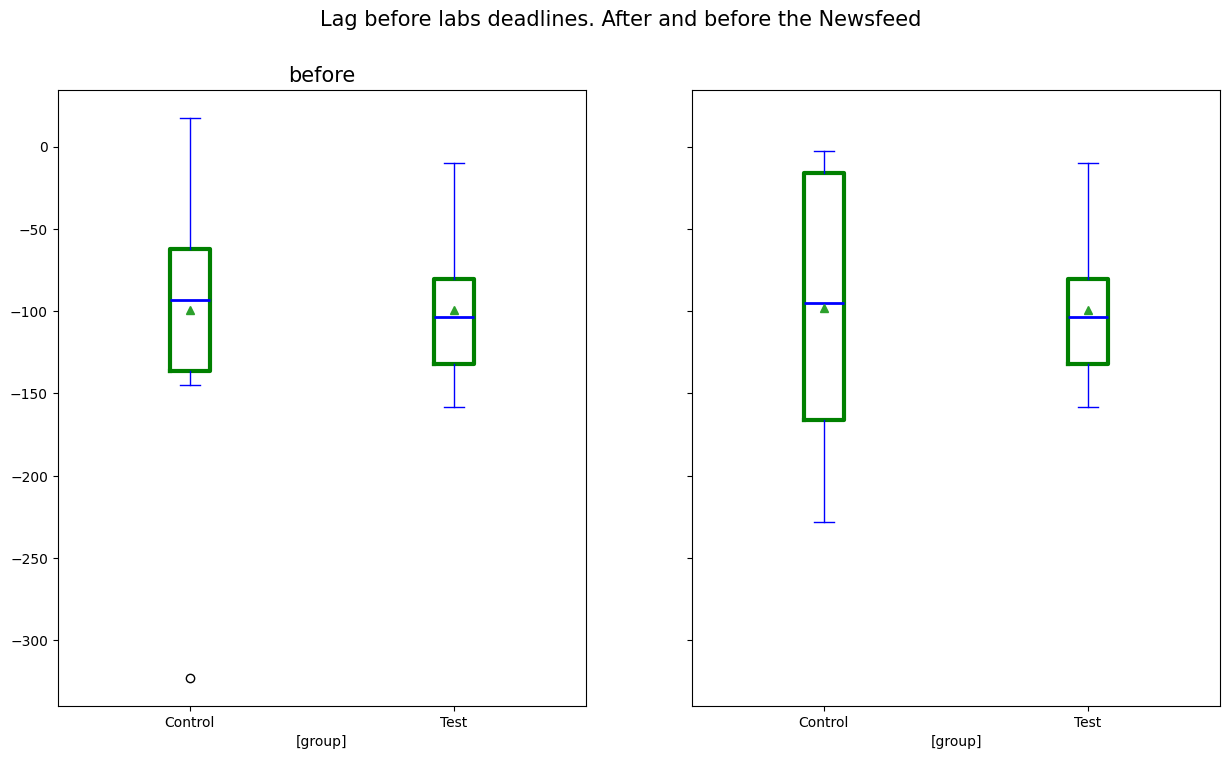

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
labels_subplot = ['Control', 'Test']
titles = ['after', 'before']
fig.suptitle("Lag before labs deadlines. After and before the Newsfeed", fontsize=15)
axes[0].boxplot(data_after,
                labels=labels_subplot,
                medianprops={'color': 'blue', 'linewidth': 2},
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'),
                boxprops={'color': 'green', 'linewidth': 3},
                showmeans=True)
axes[0].set_title(titles[0], fontsize=15)
axes[0].grid

axes[1].boxplot(data_before,
                labels=labels_subplot,
                medianprops={'color': 'blue', 'linewidth': 2},
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'),
                boxprops={'color': 'green', 'linewidth': 3},
                showmeans=True)

axes[0].set_title(titles[1], fontsize=15)
axes[0].grid

all_data = []
for group in data_after + data_before:
    all_data.extend(group)

y_min = min(all_data)
y_max = max(all_data)

range_data = y_max - y_min
padding = range_data * 0.05

y_min_pad = y_min - padding
y_max_pad = y_max + padding

axes[0].set_ylim(y_min_pad, y_max_pad)
axes[1].set_ylim(y_min_pad, y_max_pad)
axes[0].set_xlabel("[group]")
axes[1].yaxis.set_ticklabels([])
axes[1].set_xlabel('[group]')

plt.show()